In [1]:
import scanpy as sc
import anndata
import glob
import os
import pandas as pd

# Define donors
donors = ["TSP21", "TSP25", "TSP27"]

# Define input and output directories (relative to the current working directory)
input_dir = "./Individual-QC-h5ad"
output_dir = "./04_Merged-PerDonor-h5ad"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Process each donor separately
for donor in donors:
    # Find all h5ad files for the donor
    donor_files = sorted(glob.glob(f"{input_dir}/{donor}_*_10X_processed.h5ad"))
    
    if not donor_files:
        print(f"No files found for {donor}, skipping...")
        continue
    
    print(f"Found {len(donor_files)} files for {donor}.")

    # Load datasets
    adatas = [sc.read_h5ad(f) for f in donor_files]

    # Ensure unique categorical values before merging
    for i, adata in enumerate(adatas):
        tissue_label = donor_files[i].split("_")[1]  # Extract tissue name from filename
        adata.obs["tissue"] = tissue_label  # Assign tissue name

        # Convert categorical columns to strings and ensure uniqueness
        for col in adata.obs.select_dtypes(["category"]).columns:
            adata.obs[col] = adata.obs[col].astype(str)
            adata.obs[col] = pd.Categorical(adata.obs[col])  # Convert back to categorical

    # Concatenate while ensuring shared genes/features
    merged_adata = anndata.concat(adatas, join="outer", label="tissue", keys=[f.split("_")[1] for f in donor_files])

    # Save merged dataset
    output_file = f"{output_dir}/{donor}_merged.h5ad"
    merged_adata.write_h5ad(output_file)

    print(f"Merged {len(donor_files)} files for {donor} and saved to {output_file}.")


Found 15 files for TSP21.
Merged 15 files for TSP21 and saved to ./04_Merged-PerDonor-h5ad/TSP21_merged.h5ad.
Found 20 files for TSP25.
Merged 20 files for TSP25 and saved to ./04_Merged-PerDonor-h5ad/TSP25_merged.h5ad.
Found 15 files for TSP27.
Merged 15 files for TSP27 and saved to ./04_Merged-PerDonor-h5ad/TSP27_merged.h5ad.


In [9]:
import scanpy as sc
import anndata
import glob
import os
import pandas as pd

adata = sc.read_h5ad("04_Merged-PerDonor-h5ad/TSP21_merged.h5ad")



/tmp/ipykernel_337705/2160322535.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="celltype_major", data=top_20_celltypes, order=top_20_celltypes["celltype_major"], palette='viridis')


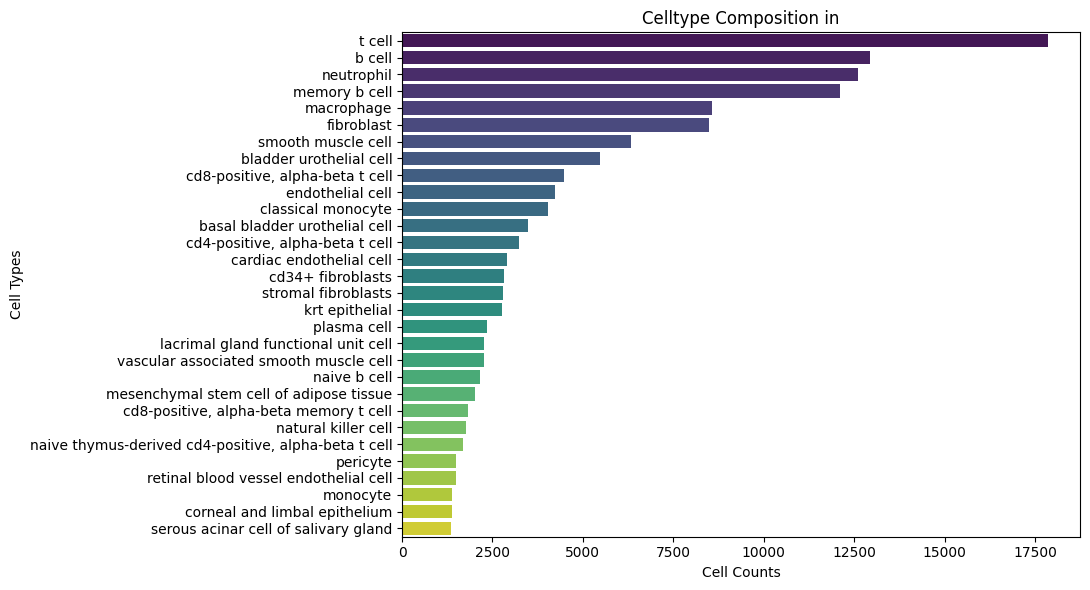

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Get the celltype counts and sort them in descending order
celltype_counts = adata.obs["free_annotation"].value_counts().reset_index()
celltype_counts.columns = ["celltype_major", "count"]
celltype_counts = celltype_counts.sort_values(by="count", ascending=False)

# Select the top 20 most populated cell types
top_20_celltypes = celltype_counts.head(30)

# Verify that the dataframe isn't empty
if top_20_celltypes.empty:
    print("No data to plot.")
else:
    # Plot without hue and fix the order
    plt.figure(figsize=(11,6))
    sns.barplot(x="count", y="celltype_major", data=top_20_celltypes, order=top_20_celltypes["celltype_major"], palette='viridis')

    # Customize the plot
    plt.title(f"Celltype Composition in")
    plt.xlabel("Cell Counts")
    plt.ylabel("Cell Types")
    plt.tight_layout()

    # Show the plot
    plt.show()


In [1]:
import scanpy as sc
import anndata
import glob
import os
import pandas as pd

adata = sc.read_h5ad("04_Merged-PerDonor-h5ad/TSP21
                     _merged.h5ad")

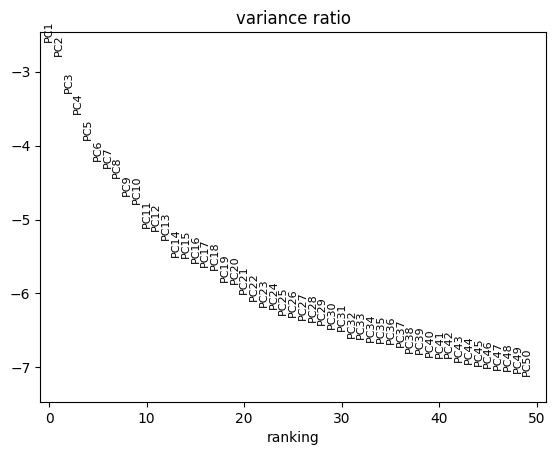

miniconda3/envs/notebook/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


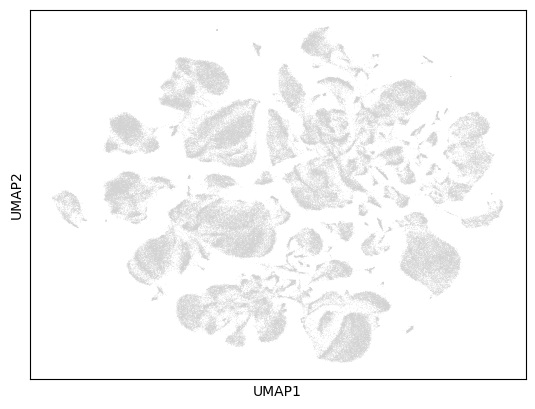

In [3]:
# Compute nearest-neighbor graph, PCA, and UMAP embeddings
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

fig = sc.pl.umap(adata, palette=["free_annotation"], title=None, return_fig=True, legend_loc= 'none')

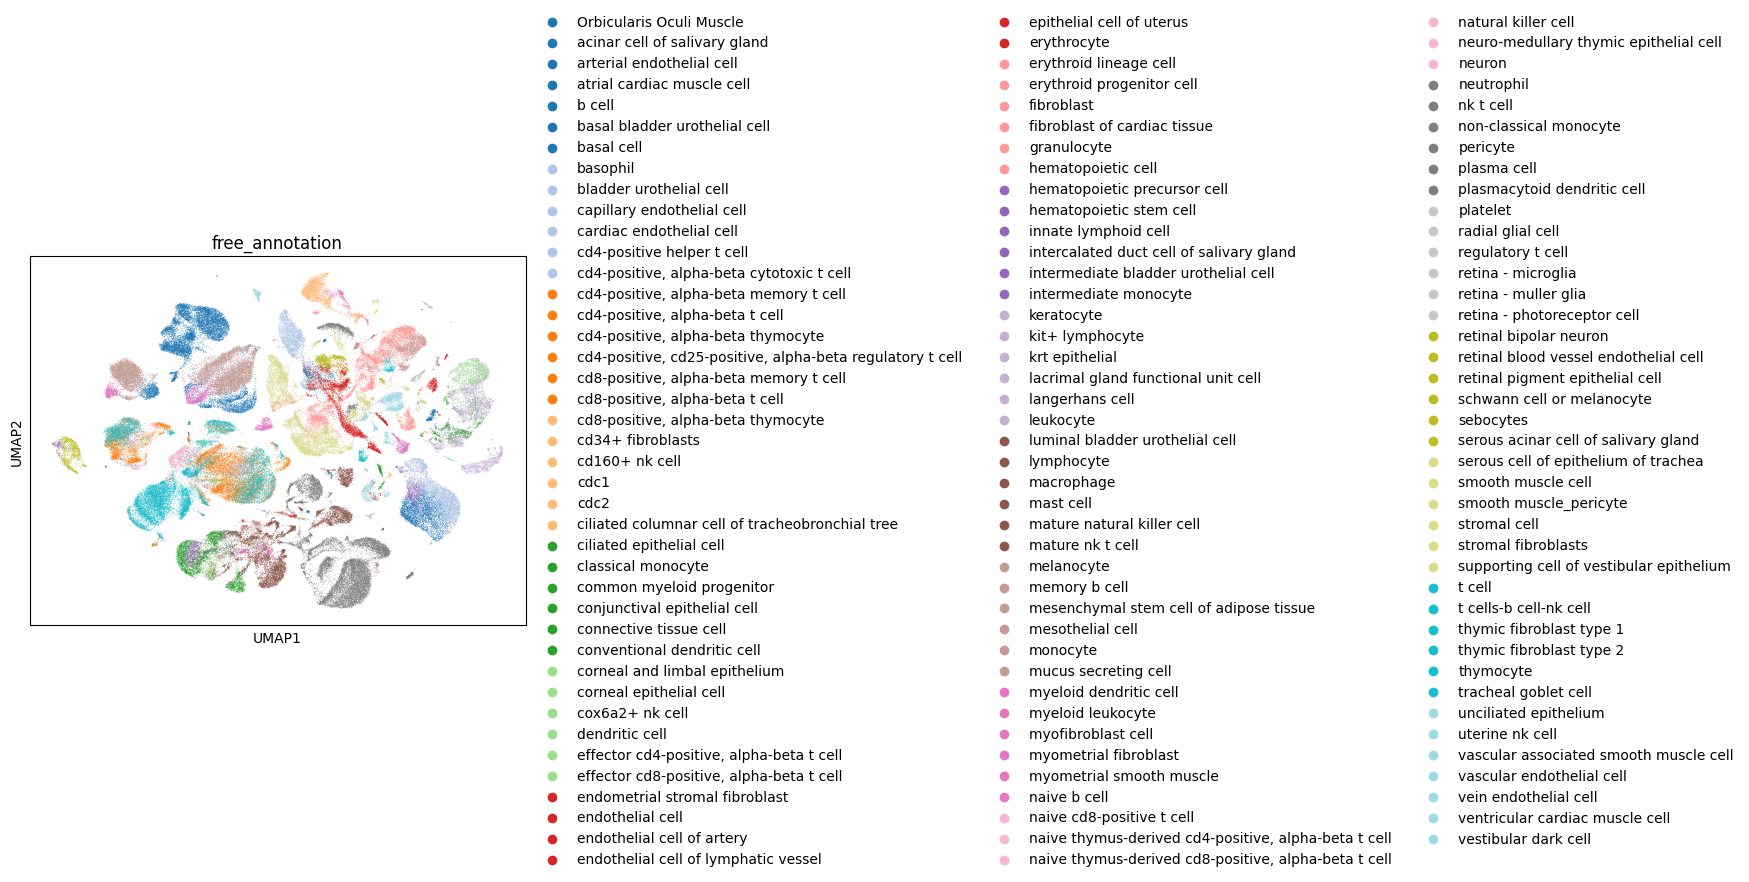

In [ ]:
fig = sc.pl.umap(adata, color=["free_annotation"], palette="tab20", title= None, return_fig=True)

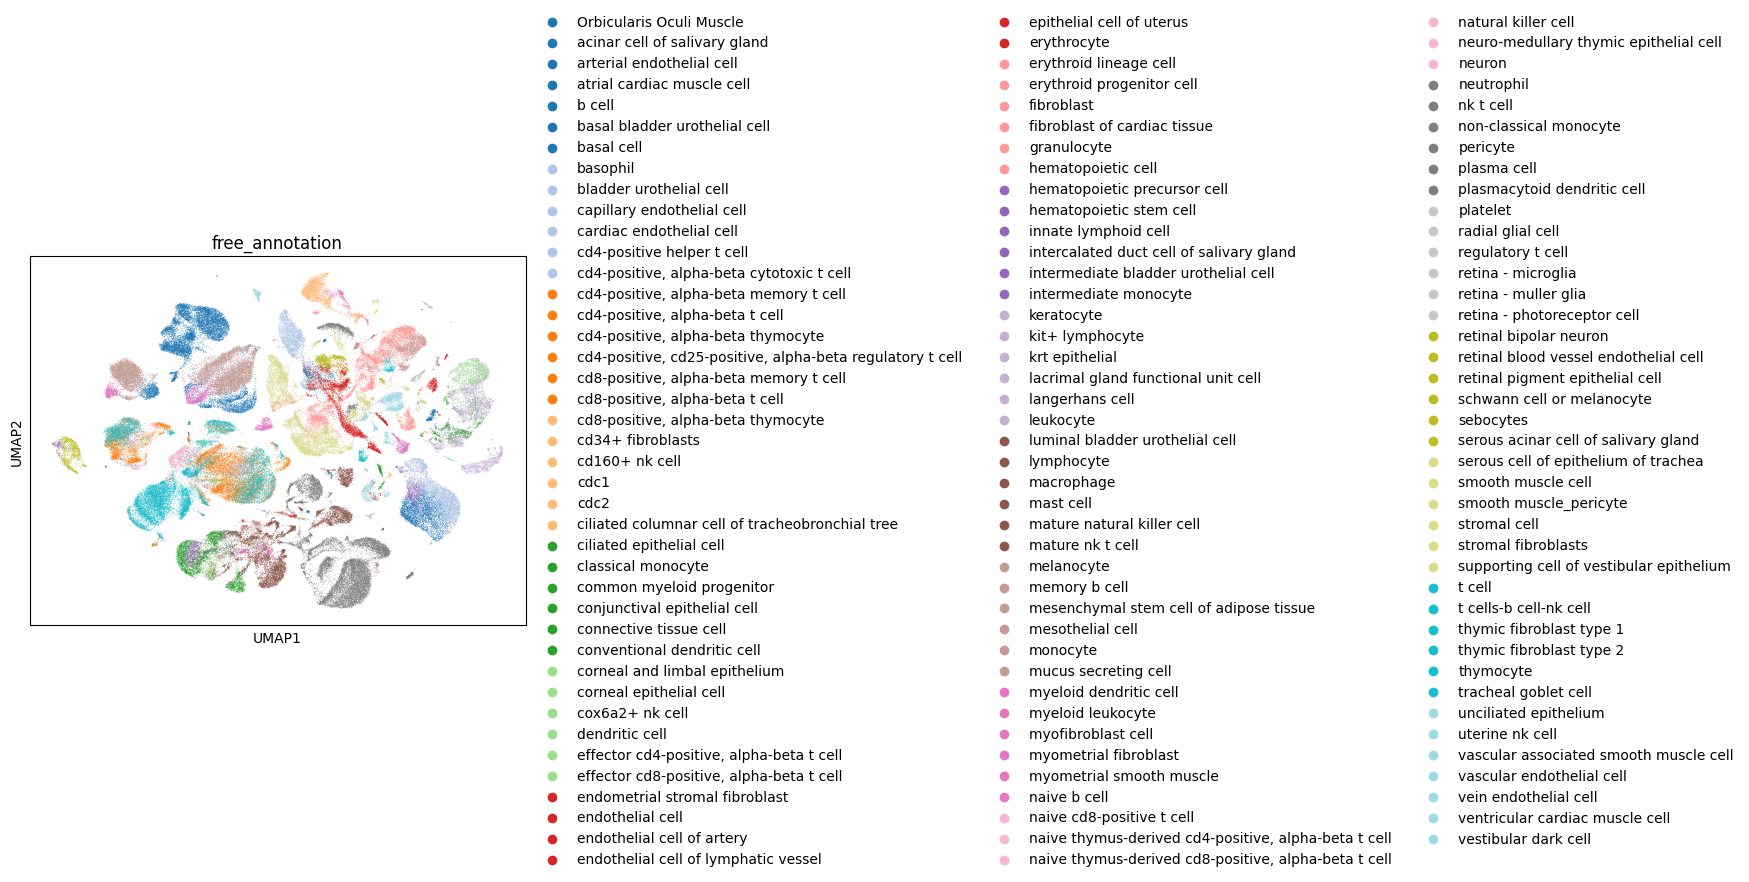

In [8]:
sc.pl.umap(adata, color=["free_annotation"], palette="tab20")
